# Introducción al TP1 (modelos de regresión)

Este notebook sirve de presentación para el TP1 de Laboratorio de Datos, 2do cuatrimestre 2026.

El enunciado de este TP es público desde el día 1/9 y hay tiempo hasta el día 15/9 para entregar los resultados.

Los grupos se clasificaron al azar en LLM- y LLM+ y la clasificación recibida por cada grupo puede consultarse en la planilla donde se anotaron (columna "LLM").

Los grupo LLM- tienen que hacer el TP sin asistencia de LLMs u otros tipos de IA generativa. Es ideal que no consulten este tipo de herramientas en ningún momento, aunque si es necesario pueden hacerlo en relación a aspectos técnicos de código (e.g. "esto no me funciona"). De todas maneras, es preferente que nos consulten a los docentes de ser posible.

Los grupos LLM+ tienen que hacer el grupo en colaboración con la herramienta de IA que prefieran, idealmente alguna herramienta basada en LLMs como Claude, Gemini o ChatGPT. No es necesario que usen una versión paga. Por ejemplo, pueden compartir los datos y enunciado y usar el LLM para formular distintos modelos y evaluarlos en los datos, luego devolverle su opinión y sus ideas al respecto, e iterar este ciclo de trabajo hasta terminar el TP.

El TP consiste en construir un modelo de regresión para un conjunto de datos numéricos y categóricos. Luego de construir y optimizar este modelo, ustedes van a poder aplicarlo a datos que no tienen etiquetas y generar una predicción numérica. El TP termina cuando ustedes nos entregan esta predicción numérica en formato csv (separado por comas) junto con el código que utilizaron para entrenar el modelo de regresión utilizado.

# Evaluación

El objetivo de este TP es evaluar su capacidad para enfrentarse a un problema y generar una solución simple pero eficaz basándose en lo visto en la materia. Por lo tanto, no pedimos informes ni presentaciones, solamente el resultado final de su modelo.

Solamente hay dos calificaciones, que son aprobado y no aprobado. Esperamos que todos aprueben el TP, pero para los que no lo hagan, hay una instancia de devolución donde pueden rehacer lo que haga falta para que el TP sea aprobado. Todos tienen que tener este TP aprobado para aprobar esta materia.

El TP se considera aprobado si entregan el .csv con las predicciones y un notebook que evidencie un intento de desarrollar un modelo de regresión no trivial. Ejemplos de modelos de regresión triviales incluyen los ejemplos incluidos en este notebook, o bien generadores de ruido o constantes numéricas que no tengan en cuenta los datos para generar las predicciones. No es necesario que el modelo supere un umbral de performance para considerarse aprobado, solamente que hayan intentando legítimamente resolver el problema en la mejor de sus capacidades.

El TP se considera no aprobado si el modelo que entregan es trivial en los sentidos mencionados en el párrafo anterior. También se considera no aprobado si los datos no permiten evaluar el desempeño de su modelo, por ejemplo, porque no son numéricos o tienen una cantidad de entradas diferente a la del vector de etiquetas. También se considera no aprobado en caso de que no entreguen nada antes de la fecha límite.

Una vez que todos los TP hayan sido entregados, vamos a construir un ranking de los mejores en cada group (LLM- y LLM+), los vamos a comparar entre grupos, y vamos a entregar fantásticos premios a los grupos ganadores.

# Datos

El dataset consta de 675 de registros de nacimientos de bebés en el Reino Unido. Cada fila es un bebé individual, sin datos faltantes. Los campos (columnas) son los siguientes.

**fage**: edad del padre (años).

**mage**: edad de la madre (años).

**mature**: clasificación de madres en maduras (igual o más de 35 años, "*mature mom*") y jóvenes (menos de 35 años, "*younger mom*").

**visits**: cantidad de visitas de la madre al obstetra durante el embarazo.

**gained**: aumento de peso de la madre desde el comienzo del embarazo (medido en libras, 1 libra = 0.45 kg).

**sex**: sexo del bebé (*male*=masculino, *female*=femenino).

**habit**: si la madre se considera fumadora (*smoker*=fumadora, *nonsmoker*=no fumadora).

**marital**: estado civil de los padres (*married*=casados, *not married*=no casados).

**whitemom**: si la madre se considera de raza blanca o no (*white*=sí, *not white*=no).












# Objetivo

**El objetivo es predecir el peso del bebé al momento de nacer (en libras).**

El desempeño de los modelos se va a medir en base al error mínimo absoluto:

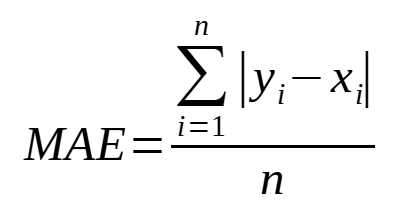

(suma del valor absoluto de la resta entre valores predichos y reales, dividido por cantidad de muestras).

Por ejemplo, un MAE de 1 indica que en promedio, las predicciones de su modelo se alejaron del resultado real por 1 libra (0.45 kg).

# Acceso a los datos

Los datos pueden accederse desde el Google Drive de la materia: https://drive.google.com/drive/folders/17q7cEmKOW65huTPWKcDF6BCmqyld3EQU?usp=sharing

**X_train.csv**: un archivo .csv con los datos para entrenar al modelo.

**y_train.csv**: los valores para predecir en el dataset de entrenamiento.

**X_test.csv**: los valores para predecir en el dataset de evaluación (lo que tienen que entregar).



# Ejemplos de modelos sencillos y cómo generar predicciones para entregar

A continuación mostramos algunos ejemplos de modelos de regresión muy sencillos que podemos usar para generar las predicciones.

En primer lugar, vamos a cargar los datos:



In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# List the contents of the TP1 folder to verify file existence and exact names
!ls '/content/drive/My Drive/LdD2026/TPs/TP1/'

data_train = '/content/drive/My Drive/LdD2026/TPs/TP1/X_train.csv'
data_labels = '/content/drive/My Drive/LdD2026/TPs/TP1/y_train.csv'
data_predict = '/content/drive/My Drive/LdD2026/TPs/TP1/X_test.csv'

# Ensure these paths match the output of the !ls command above.
# If the files are in a different folder or have different names, update the paths accordingly.
X_train = pd.read_csv(data_train)
y_train = pd.read_csv(data_labels)
X_test = pd.read_csv(data_predict)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TPs  X_test.csv  X_train.csv  y_train.csv


Vamos a construir un par de modelos sencillos.

1. **Regresión univariada** con el peso ganado por la madre en el embarazo.

1. **Regresión multivariada** con el peso ganado y la edad de la madre.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np


# modelo basado en peso (gained)

X = np.array(X_train['gained']).reshape(-1, 1)     # matriz de entrenamiento
y = np.array(y_train['weight'])                    # matriz de entrenamiento
reg = LinearRegression()                           # crea el regresor
reg.fit(X,y)                                       # estima parametros
y_pred = reg.predict(X)                            # predice en los datos de entrenamiento
MAE = mean_absolute_error(y, y_pred)

print("Modelo basado en gained:")
print(MAE)

# modelo basado en peso+edad (gained+mage)
X = np.array(X_train[['gained','mage']])
y = np.array(y_train['weight'])
reg = LinearRegression()
reg.fit(X,y)
y_pred = reg.predict(X)
MAE = mean_absolute_error(y, y_pred)

print("Modelo basado en gained+mage:")
print(MAE)

Modelo basado en gained:
0.9051583564168633
Modelo basado en gained+mage:
0.901100597721988


Supongamos que vamos a querer usar el segundo modelo.

Entonces, para generar y guardar las predicciones sobre X_test (**lo que tienen que entregarnos**) tienen que hacer:

In [ ]:
from google.colab import files

X_entrega = np.array(X_test[['gained','mage']])    #saca de X_test las features que usamos para entrenar
y_pred_entrega = reg.predict(X_entrega)                    #genera las predicciones

print(y_pred_entrega.shape)                        #verificar que las dimensiones esten bien!

np.savetxt('grupoX.csv', y_pred_entrega, delimiter=',')       #un unico archivo con este formato (X=numero de grupo) y con coma de delimitador
files.download('grupoX.csv')                                  #y lo descargamos

(119,)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Un poco más sobre los modelos

Tenemos motivos para creer que el MAE que obtuvimos está inflado respecto del que vamos a obtener en el conjunto X_test, que es el que vamos a usar para evaluar el desempeño.

Esto es porque el modelo fue entrenado y evaluado en el mismo conjunto de datos (X_train) y entonces, como vamos a ver en las próximas clases, puede haber sobreajuste.

Para tener un estimativo más real del desempeño del modelo, podemos dejar de lado un conjunto de datos que no usamos para entrenar el modelo y luego evaluar cómo nos fue ahí. De esta manera, podemos tratar de entregar las predicciones del modelo al que le vaya mejor en este sentido.

Por ejemplo, podemos hacer:

In [ ]:
from sklearn.model_selection import train_test_split

X = np.array(X_train[['gained','mage']])
y = np.array(y_train['weight'])

X_subtrain, X_subtest, y_subtrain, y_subtest = train_test_split(
    X, y, test_size=0.10)          # uso el 10% para evaluar

reg = LinearRegression()
reg.fit(X_subtrain,y_subtrain)
y_pred = reg.predict(X_subtest)
MAE = mean_absolute_error(y_subtest, y_pred)

print("Modelo basado en gained+mage:")
print(MAE)

Modelo basado en gained+mage:
1.0534158758776697


Si se fijan, van a darse cuenta de que en cada vez que corren el modelo les da un resultado bastante diferente. Esto es porque hay una aleatoridad intrínseca a qué samples van a parar al dataset de entrenamiento. Para mitigar este problema, podemos repetir muchas veces usando distintos conjuntos de entrenamiento, guardar los resultados en una lista, y calcular el promedio y visualizar la distribución.



MAE promedio:
0.9129847657856979


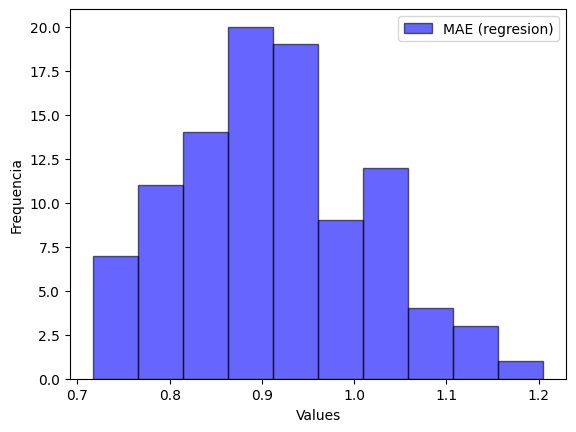

In [ ]:
import matplotlib.pyplot as plt

all_MAEs = []   # guardamos los MAE
all_ys = np.array([])    # guardamos los valores a predecir
all_preds = np.array([])  # guardamos las predicciones
all_R2 = []               # R2, lo usamos despues

niters = 100

for n in np.arange(niters):
  X_subtrain, X_subtest, y_subtrain, y_subtest = train_test_split(
    X, y, test_size=0.10)          # uso el 10% para evaluar

  reg = LinearRegression()
  reg.fit(X_subtrain,y_subtrain)
  y_pred = reg.predict(X_subtest)
  MAE = mean_absolute_error(y_subtest, y_pred)
  R2 = r2_score(y_subtest,y_pred)
  all_ys = np.concatenate((all_ys, y_subtest))
  all_preds = np.concatenate((all_preds, y_pred))
  all_MAEs.append(MAE)
  all_R2.append(R2)

all_MAEs = np.array(all_MAEs)

print("MAE promedio:")
print(np.mean(all_MAEs))

plt.hist(all_MAEs,  alpha=0.6, label='MAE (regresion)', color='blue', edgecolor='black')
plt.xlabel('Valores'); plt.ylabel('Frequencia')
plt.legend(); plt.show()




Otra cosa que puede servir es evaluar qué tan buena es la predicción respecto de un modelo trivial, por ejemplo, un modelo que predice siempre la misma edad (el promedio).



MAE promedio (constante):
0.9170870469522242


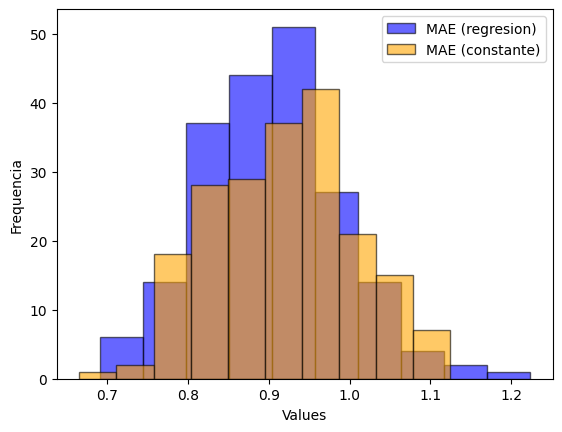

In [ ]:
all_MAEs_constant = []

niters = 200

for n in np.arange(niters):
  X_subtrain, X_subtest, y_subtrain, y_subtest = train_test_split(
    X, y, test_size=0.10)          # uso el 10% para evaluar

  y_pred = np.mean(y_subtrain)*np.ones(y_subtest.shape[0])
  MAE = mean_absolute_error(y_subtest, y_pred)
  all_MAEs_constant.append(MAE)


all_MAEs_constant = np.array(all_MAEs_constant)

print("MAE promedio (constante):")
print(np.mean(all_MAEs_constant))


plt.hist(all_MAEs,  alpha=0.6, label='MAE (regresion)', color='blue', edgecolor='black')
plt.hist(all_MAEs_constant,  alpha=0.6, label='MAE (constante)', color='orange', edgecolor='black')
plt.xlabel('Valores'); plt.ylabel('Frequencia')
plt.legend(); plt.show()

Más adelante vamos a ver otras mejores formas de hacerlo, como validación cruzada.

Pero de momento, no parece que esté funcionando mucho mejor que una constante.

Podemos verificar esto fácilmente si ploteamos la predicción vs. el valor real:



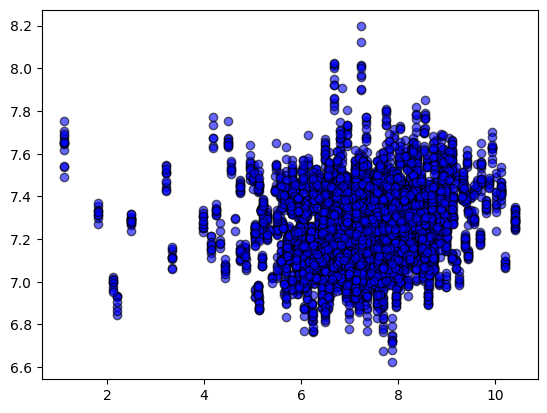

In [ ]:
plt.scatter(all_ys, all_preds, color='blue', alpha=0.6, edgecolors='k')

plt.xlabel('Valores reales', fontsize=12)
plt.ylabel('Valores predichos', fontsize=12)


Notar que cada punto aparece muchas veces en el eje x porque estamos iterando con reemplazo sobre el conjunto de datos cuando estimamos el MAE. Este es el tipo de problemas que se resuelven haciendo validación cruzada.

Otra forma de entender si nuestro modelo está capturando algo más que una predicción constante es computar el coeficiente R2:

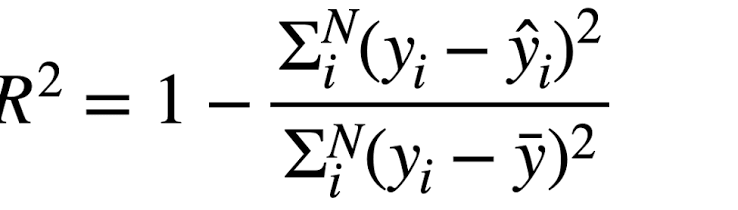

Este coeficiente representa 1 menos la varianza no explicada por el modelo (numerador) dividada por la varianza de los datos (denominador). Es 1 cuando el modelo es perfecto, es decir, cuando todas las predicciones individuales son correctas. Es 0 cuando la varianza no explicada por el modelo es igual a la varianza de los datos. Puede ser negativa cuando el modelo explica menos que la varianza de los datos.

En nuestro caso, el R2 da:

In [ ]:
print("Valor de R2 (regresion):")
print(np.mean(all_R2))

Valor de R2 (regresion):
-0.007850532851287027


Como es de esperarse, es cercano a cero. Esperamos que un mejor modelo no solamente mejor en términos del MAE sino del R2, aunque solo vamos a usar el MAE para rankear sus resultados.

Cabe preguntarse si es posible hacer una predicción con R2 positivo en estos datos. **La respuesta es sí**. No solamente vamos a comparar los grupos LLM- con LLM+, sino también con los resultados de un LLM trabajando sin supervisión humana (ChatGPT 5.5, OpenAI).

Para referencia, los resultados del modelo desarrollado por ChatGPT en el conjunto de prueba final son:

**R2 = 0.099**

**MAE = 1.07**

# Algunos tips para el TP

1.   No todos los datos son numéricos, algunos son categóricos. Estos datos se pueden usar, pero hay que transformarlos antes a variables binarias.
2.   Usar una regresión lineal puede ser demasiado simple para tener un modelo bueno, pero tampoco hace falta complicarla demasiado. Pueden probar agregando regularización a un modelo lineal.
3.   Si usan regularización, es recomendable que ajusten la constante de regularización, optimizandola en los datos de entrenamiento (por ejemplo, mediante validación cruzada)
4.   Pueden crear nuevos features en base los que tienen, por ejemplo, poniendo umbrales, dividiendo variables continuas en categorías, o multiplicando variables entre sí (interacciones)
5.   **Al final del día lo importante es que aprueben el TP, así que hagan un esfuerzo honesto y entreguen predicciones en el formato requerido antes de la fecha límite.**

